## Trabajo en Clase: Ingeniería de Atributos - Automobile Dataset

**Dataset**: Usaremos el **Automobile Dataset**, que contiene diversas características técnicas de vehículos y su precio de mercado. Este dataset es ideal para practicar técnicas de transformación de variables y creación de nuevos atributos.

**Descripción del dataset**: https://www.kaggle.com/datasets/toramky/automobile-dataset/data

**URL del Dataset**: Desde el propio Kaggle o de [este link](https://drive.google.com/file/d/1WtYT7g0PJ287UwalVAbu5YBt4cA9eeiq/view?usp=drive_link)

### Instrucciones:

1. **Carga y Preparación de Datos**:
    - Cargar el archivo `Automobile_data.csv`.
    - Identificar y reemplazar los valores faltantes marcados con el carácter `?` por `NaN`.
    - La variable objetivo es `price`. Eliminar los registros donde el precio no sea numérico o esté ausente.
    - Convertir las columnas numéricas que se cargaron como objetos (debido al `?`) a tipo float e imputar sus valores faltantes con la media.

2. **Modelo Baseline**:
    - Definir un modelo de `RandomForestRegressor` y evaluar su desempeño (RMSE) utilizando validación cruzada (`cross_val_score`).
    - Utilizar inicialmente solo las variables numéricas originales para establecer el baseline.

3. **Codificación de Variables Categóricas**:
    - Aplicar técnicas de **Label Encoding** y **One-Hot Encoding** a las variables categóricas.
    - Comparar cómo cambia el RMSE y la cantidad de columnas (shape) resultante en cada caso.

4. **Creación de Atributos (Feature Construction)**:
    - Crear al menos 5 nuevas columnas matemáticas derivadas que aporten valor predictivo. Ejemplos:
        - Relación Peso-Potencia (`horsepower` / `curb-weight`).
        - Eficiencia del motor (`horsepower` / `engine-size`).
        - Consumo promedio combinado (`city-mpg` y `highway-mpg`).
        - *Nota: Tener cuidado con el Data Leakage al usar la variable objetivo en nuevas features.*

5. **Escalamiento y Normalización**:
    - Aplicar **Min-Max Scaling** y **Z-Score Standardization** a las variables numéricas.
    - Evaluar si estas transformaciones impactan positivamente en el modelo de Random Forest.

6. **Transformaciones de Distribución**:
    - Aplicar transformaciones de **Logaritmo**, **Raíz Cuadrada** y **Yeo-Johnson** (usando `PowerTransformer`).

7. **Discretización (Binning)**:
    - Transformar variables continuas en categóricas usando binning de **Igual Frecuencia** e **Igual Ancho**.
    - Probar técnicas más avanzadas como binning basado en **KMeans**.

8. **Técnicas Supervisadas (Avanzado)**:
    - Implementar discretización basada en **Entropía** (usando un árbol de decisión para encontrar los mejores cortes).
    - Calcular el **Weight of Evidence (WoE)** para una variable seleccionada.

9. **Comparativa Global**:
    - Mantener un registro de los resultados de cada experimento y presentar una tabla comparativa final con el RMSE y la cantidad de features de cada aproximación.

**Tips**:
- Utilizar una función para graficar la importancia de los atributos (`feature_importances_`) después de cada entrenamiento.
- Para las transformaciones que requieren valores positivos, tener la precaución de desplazar la distribución si existen valores negativos o cero.
- Random Forest es robusto a la escala, pero las transformaciones de distribución y la creación de atributos pueden revelar relaciones que el modelo base no captura fácilmente.

**Resultado esperado**: Un DataFrame con el conjunto final de características transformadas y un reporte de RMSE que demuestre la mejora respecto al baseline.

# 1. Carga y Preparación de Datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [ ]:
df = pd.read_csv('/content/Automobile_data.csv')
df.shape

(205, 26)

In [ ]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [ ]:
# Eliminamos registros donde price no está presente, ya que es nuestra variable objetivo
df_test = df[df["price"] == '?'].copy()
df = df[df["price"] != '?'].copy()

In [ ]:
# Transformemos los '?' en NaNs
df.replace('?', pd.NA, inplace=True)

# A las columnas que queramos imputar para despues, las pasamos a numericas y le imputamos cero
cols_numericas = [
    "normalized-losses",
    "horsepower",
    "price",
    "bore",
    "stroke",
    "peak-rpm",
]
df[cols_numericas] = df[cols_numericas].apply(pd.to_numeric, errors='coerce')
df['num-of-doors'] = df['num-of-doors'].map({'four': 4, 'two': 2, pd.NA: 4})
df['num-of-cylinders'] = df['num-of-cylinders'].map({
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12,
})

df[cols_numericas] = df[cols_numericas].fillna(df.mean(numeric_only=True))

In [ ]:
def feature_importances(modelo, df, topn=10):
    importances = modelo.feature_importances_
    indices = np.argsort(importances)[-topn:]

    plt.barh(range(len(importances[-topn:])), importances[indices])
    plt.yticks(range(len(importances[-topn:])), df.columns[indices])
    plt.title("Feature Importances")
    plt.tight_layout()
    plt.show()

Se arma un diccionario para ir recopilando información de cada experimento:

In [ ]:
results = {
    "nombre modelo": [],
    "RMSE score": [],
    "shape": [],
}

# 2. Modelo Baseline

RMSE Baseline Score: 3768.72


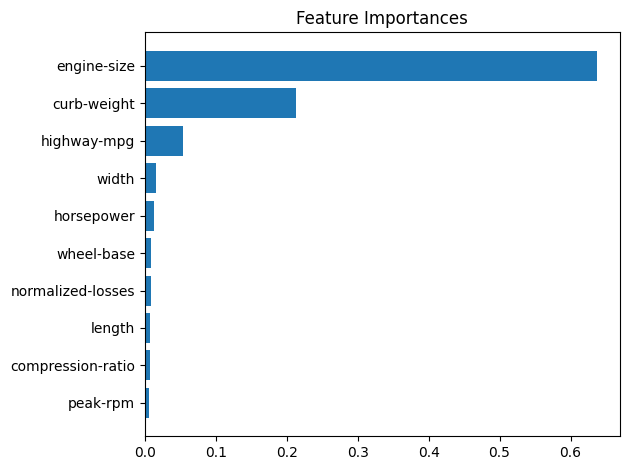

  nombre modelo   RMSE score      shape
0    1-Baseline  3768.719268  (201, 17)


In [ ]:
# Primer proceso predictivo
X = df.copy()
y = X.pop('price')

# Nuestro baseline tendrá solo las columnas numéricas originales
nombre_modelo = "Baseline"

X = X.select_dtypes(include='number')
baseline = RandomForestRegressor(n_jobs=-1, random_state=42)
baseline_score = cross_val_score(baseline, X, y, cv=5, scoring='neg_root_mean_squared_error').mean()
baseline_score = -1 * baseline_score.mean()

# Reportes de resultados
print(f"RMSE {nombre_modelo} Score: {baseline_score:.2f}")
baseline.fit(X, y)
feature_importances(baseline, X)
results["nombre modelo"].append(f"{len(results['nombre modelo']) + 1}-{nombre_modelo}")
results["RMSE score"].append(baseline_score)
results["shape"].append(X.shape)
print(pd.DataFrame(results).sort_values("RMSE score"))

# 3. Codificación de Variables Categóricas


## 3.1 Label Encoding

RMSE Label Encoding Score: 3694.47


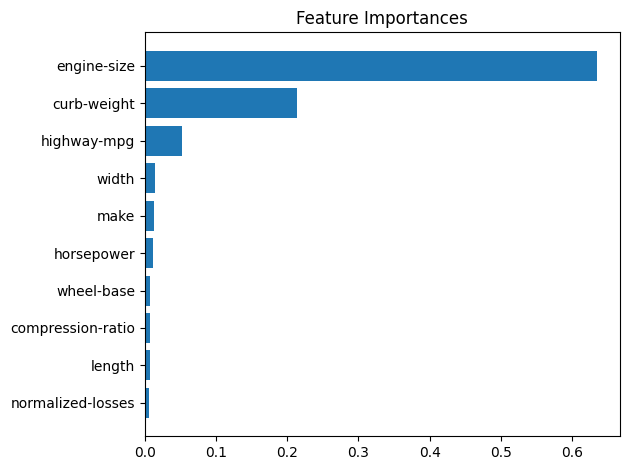

      nombre modelo   RMSE score      shape
1  2-Label Encoding  3694.473581  (201, 25)
0        1-Baseline  3768.719268  (201, 17)


In [ ]:
# Primer proceso predictivo
X = df.copy()
y = X.pop('price')

# Nuestro baseline tendrá solo las columnas numéricas originales
nombre_modelo = "Label Encoding"

# Código para label encoding acá

X = X.select_dtypes(include='number')
model = RandomForestRegressor(n_jobs=-1, random_state=42)
model_score = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error').mean()
model_score = -1 * model_score.mean()

# Reportes de resultados
print(f"RMSE {nombre_modelo} Score: {model_score:.2f}")
model.fit(X, y)
feature_importances(model, X)
results["nombre modelo"].append(f"{len(results['nombre modelo']) + 1}-{nombre_modelo}")
results["RMSE score"].append(model_score)
results["shape"].append(X.shape)
print(pd.DataFrame(results).sort_values("RMSE score"))

## 3.2 One-Hot Encoding